# Improved Regression Model

## Adding Features to the Data

In [1]:
# Modules
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
import plotly.express as px
import sklearn
import numpy as np

import geopandas as gpd
import shapely.geometry as point

- Load existing dataset

In [2]:
df = pd.read_csv('../Data/housingNoMissing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Max Price
- Add column isMax which is 1 if median price = $500,000

In [3]:
df['isMax'] = (df['median_house_value'] >= 500000).astype(int)

### City and County
- Add column of city based on lat and long or rural
- City boundaries from [here](https://gis.data.ca.gov/datasets/California::california-city-boundaries-and-identifiers/explore)

In [4]:
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"  # WGS84
)

#City boundaries shapefile
cities = gpd.read_file('../Data/California_City_Boundaries_and_Identifiers.shp')
cities = cities.to_crs(gdf_points.crs)

#classify points based on whether they fall within a city boundary
classified = gpd.sjoin(gdf_points, cities, how="left", predicate="within")
#print(classified.columns)

#print(classified['CDTFA_CITY'])

classified["CDTFA_CITY"] = classified["CDTFA_CITY"].fillna("Rural")

classified = classified.drop(columns=['geometry', 'index_right', 'CDTFA_COPR','CENSUS_PLA',
       'CENSUS_GEO', 'CENSUS_P_1', 'GNIS_PLACE', 'GNIS_ID', 'CDT_CITY_A',
       'CDT_COUNTY', 'PRIMARY_DO', 'CENSUS_POP', 'CDT_NAME_S', 'OFFSHORE',
       'AREA_SQMI', 'GlobalID'])
dfGeo = pd.DataFrame(classified)

dfGeo.rename(columns={"CDTFA_CITY": "city"}, inplace=True)
dfGeo.rename(columns={"CDTFA_COUN": "county"}, inplace=True)


- Plot city on map to check has worked
    - *has worked but is very granular*
    - County will be more useful as far less values

In [5]:
fig = px.scatter_map(dfGeo, lat="latitude", lon="longitude", color='city')
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [6]:
fig = px.scatter_map(dfGeo, lat="latitude", lon="longitude", color='county')
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [7]:
print('Distinct cities:', dfGeo['city'].nunique())
print('Distinct counties:', dfGeo['county'].nunique())

Distinct cities: 461
Distinct counties: 51


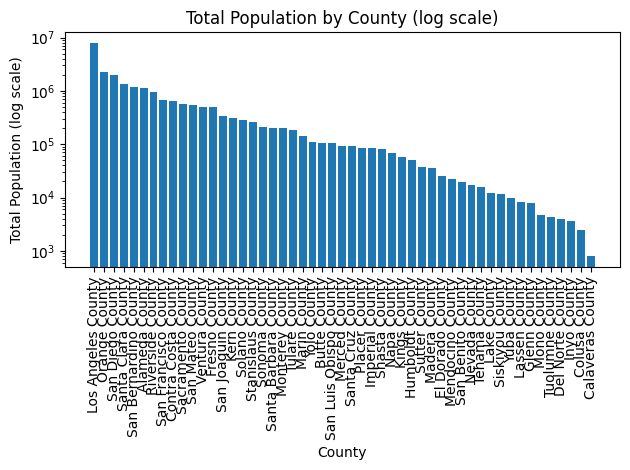

In [8]:
# sum population per county
county_pop = dfGeo.groupby('county', as_index=False)['population'].sum().rename(columns={'population':'total_population'})

# view sorted totals
county_pop = county_pop.sort_values('total_population', ascending=False)
county_pop.head()

plt.bar(county_pop['county'], county_pop['total_population'])
plt.yscale('log')
plt.xticks(rotation=90)


plt.title('Total Population by County (log scale)')
plt.ylabel('Total Population (log scale)')
plt.xlabel('County')
plt.tight_layout()

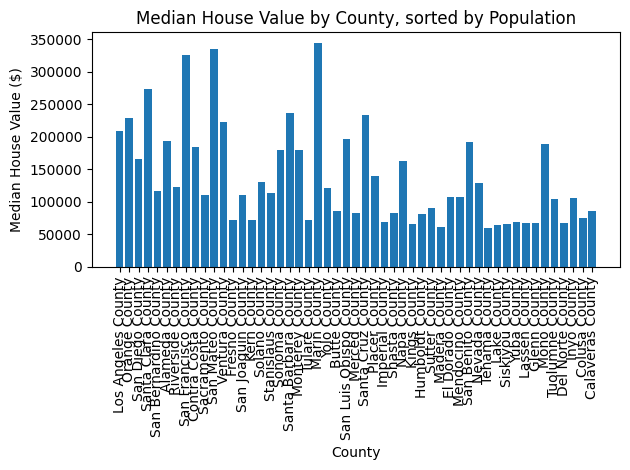

In [9]:
# median house value by county
county_price = dfGeo.groupby('county', as_index=False)['median_house_value'].median().rename(columns={'median_house_value':'median_price_by_county'})
county_price = county_price.set_index('county').reindex(county_pop['county']).reset_index()

plt.bar(county_price['county'], county_price['median_price_by_county'], width =0.8)
plt.xticks(rotation=90)
plt.title('Median House Value by County, sorted by Population')
plt.ylabel('Median House Value ($)')
plt.xlabel('County')
plt.tight_layout()

No huge pattern so probably shouldn't combine any - was thinking to keep top 10 only but doesn't look to be a good idea

## Regression Inputs
Specify which columns to keep as input to regression model
- Remove lat, long and ocean proxmity and city so that county is only geographic data

In [35]:
print(dfGeo.columns)


dfReg = dfGeo[['total_rooms', 'total_bedrooms', 'population',
                       'households', 'median_income',
                       'median_house_value', 'ocean_proximity', 'isMax', 'county']]


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'isMax', 'city', 'county',
       'total_rooms_log', 'total_bedrooms_log', 'population_log',
       'households_log', 'median_income_log', 'median_house_value_log'],
      dtype='object')


In [36]:
# do one hot encoding on 'county' categorical variable

def oneHotEncoding(df):
    """One Hot Encoding for a specific column in a dataframe.
    columnName: str
    df: pandas DataFrame
    """
    categoricalColumns = df.select_dtypes(include=['object']).columns.tolist()
    encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False)
    encodedArray = encoder.fit_transform(df[categoricalColumns])

    encodedDf = pd.DataFrame(encodedArray, columns=encoder.get_feature_names_out(categoricalColumns))
    df = pd.concat([df, encodedDf], axis=1)
    df = df.drop(columns=categoricalColumns)
    return df

dfIn = oneHotEncoding(dfReg)

## Test Train Split

In [37]:
dfTrain, dfTest = sklearn.model_selection.train_test_split(dfIn, test_size=0.2)

## Train Linear Model

In [38]:

reg = sklearn.linear_model.LinearRegression().fit(dfTrain.drop(columns=['median_house_value']), dfTrain['median_house_value'])


## Test Linear Model

Mean Absolute Error: 43831.08668573456
Root Mean Squared Error: 60587.6411143963
Predictions < $0: 1
Predictions > $500,000: 107


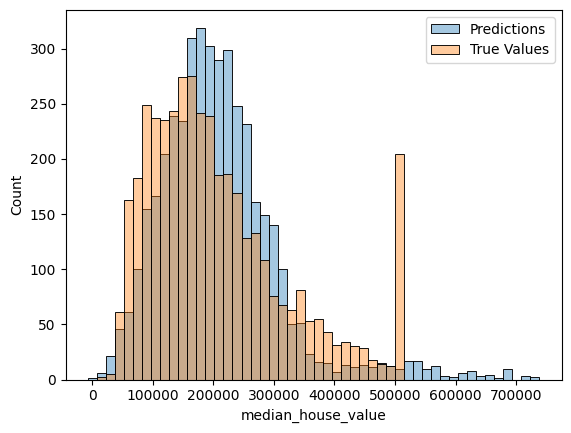

In [39]:
testPredicitions = reg.predict(dfTest.drop(columns=['median_house_value']))

fig, ax1 = plt.subplots()
bin_edges = np.linspace(min(dfTest['median_house_value'].min(), testPredicitions.min()),
                       max(dfTest['median_house_value'].max(), testPredicitions.max()),
                       51)  # 50 bins, 51 edges

sns.histplot(testPredicitions, bins=bin_edges, label='Predictions', kde=False, alpha=0.4, ax=ax1)
sns.histplot(dfTest['median_house_value'], bins=bin_edges, label='True Values', kde=False, alpha=0.4, ax=ax1)

ax1.legend()


print('Mean Absolute Error:', sklearn.metrics.mean_absolute_error(dfTest['median_house_value'], testPredicitions))
print('Root Mean Squared Error:', sklearn.metrics.mean_squared_error(dfTest['median_house_value'], testPredicitions)**0.5)

print('Predictions < $0:', (testPredicitions < 0).sum())
print('Predictions > $500,000:', (testPredicitions > 500000).sum())

- Not that much better with extra features and still basic regression
    - both MAE and RMSE ~$5,000 less

## Train Quantile Model
Use quantile regression instead to avoid issue with price cap

In [40]:
from sklearn.linear_model import QuantileRegressor

XTrain = dfTrain.drop(columns=['median_house_value'])
yTrain = dfTrain['median_house_value']

xTest = dfTest.drop(columns=['median_house_value'])
yTestTrue = dfTest['median_house_value']

QReg = QuantileRegressor(quantile=0.5, alpha=0).fit(XTrain, yTrain)
y_pred = QReg.predict(xTest)


Mean Absolute Error: 42602.16313671346
Root Mean Squared Error: 61561.1876817996
Predictions < $0: 1
Predictions > $500,000: 107


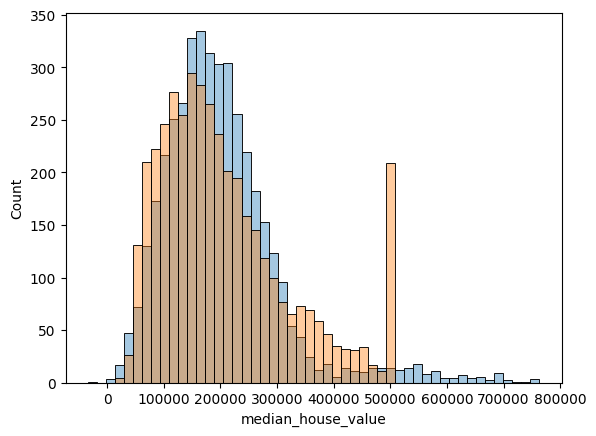

In [41]:
fig2, ax2 = plt.subplots()
bin_edges = np.linspace(min(dfTest['median_house_value'].min(), y_pred.min()),
                       max(dfTest['median_house_value'].max(), y_pred.max()),
                       51)  # 50 bins, 51 edges

sns.histplot(y_pred, bins=bin_edges, label='Predictions', kde=False, alpha=0.4, ax=ax2)
sns.histplot(yTestTrue, bins=bin_edges, label='True Values', kde=False, alpha=0.4, ax=ax2)

ax1.legend()


print('Mean Absolute Error:', sklearn.metrics.mean_absolute_error(yTestTrue, y_pred))
print('Root Mean Squared Error:', sklearn.metrics.mean_squared_error(yTestTrue, y_pred)**0.5)

print('Predictions < $0:', (testPredicitions < 0).sum())
print('Predictions > $500,000:', (testPredicitions > 500000).sum())

Similar performance, error mainly coming from capped values still

## Log of input values
- Several categories are log normally distributed, add variables for each of these

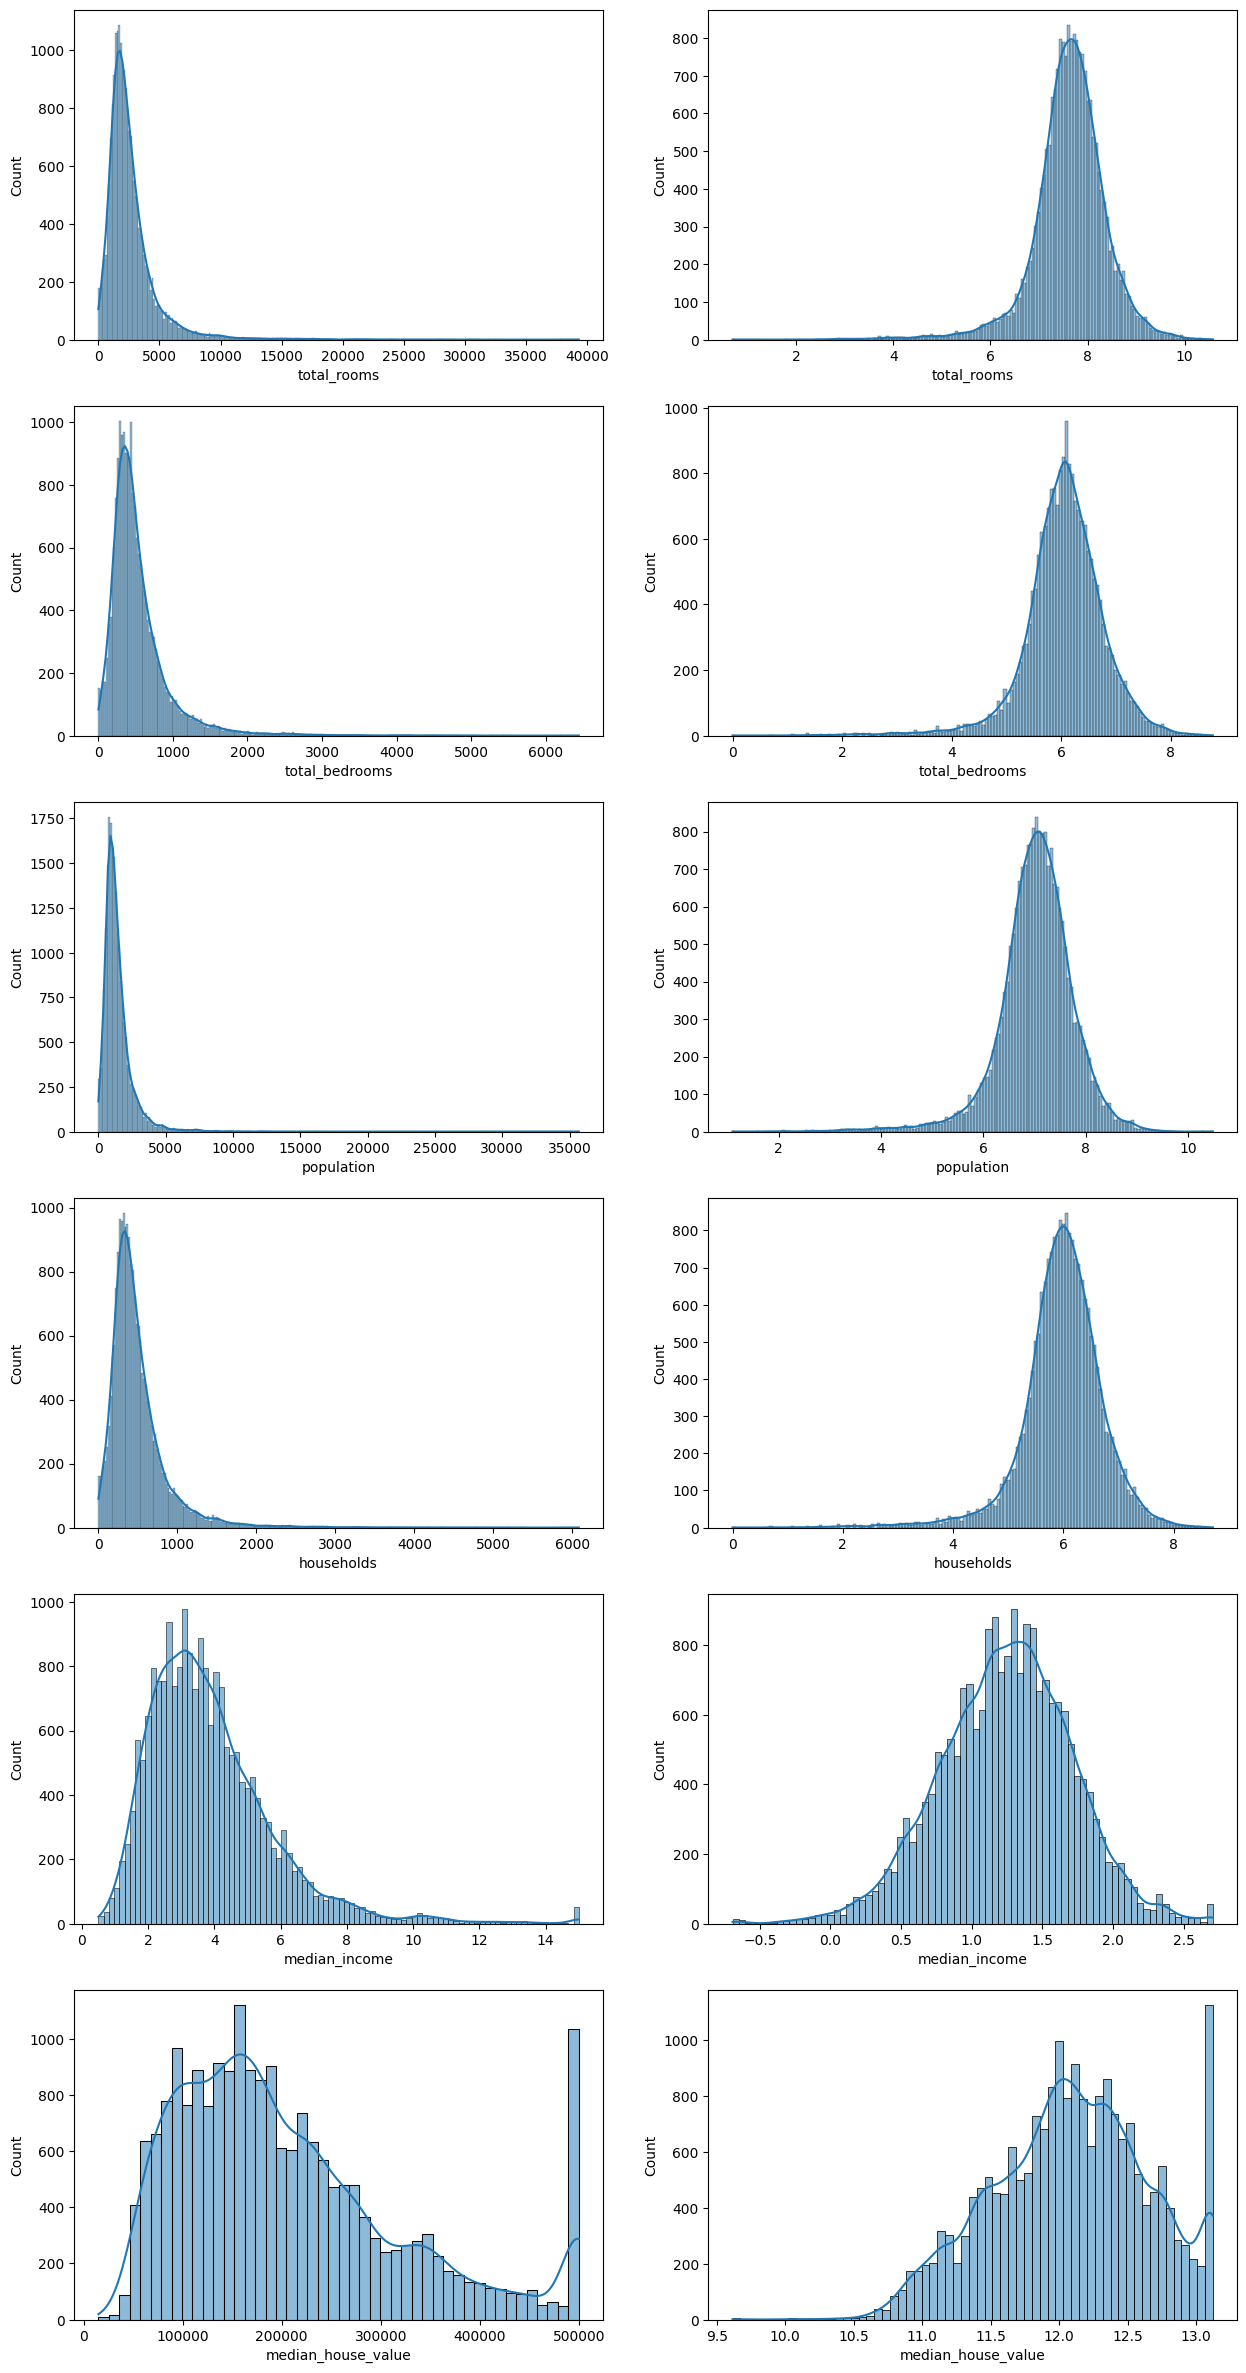

In [17]:
categories = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
figLN, axsLN = plt.subplots(len(categories),2, figsize=(15,30))
for i in range(0, len(categories)):
    sns.histplot(data=df, x=categories[i], ax=axsLN[i,0], kde=True)
    sns.histplot(np.log(df[categories[i]]), ax=axsLN[i,1], kde=True)
    #axsLN[i, 1].set_xscale('log')

All look better when taken the log of

In [23]:
dfGeo['total_rooms_log'] = np.log(dfGeo['total_rooms'])
dfGeo['total_bedrooms_log'] = np.log(dfGeo['total_bedrooms'])
dfGeo['population_log'] = np.log(dfGeo['population'])
dfGeo['households_log'] = np.log(dfGeo['households'])
dfGeo['median_income_log'] = np.log(dfGeo['median_income'])

In [42]:
dfRegLog = dfGeo[['total_rooms_log',
       'total_bedrooms_log', 'population_log', 'households_log', 'median_income_log',
       'median_house_value', 'ocean_proximity', 'isMax', 'county']]

## Train Quantile Model

In [54]:
dfInLog = oneHotEncoding(dfRegLog)
dfTrainLog, dfTestLog = sklearn.model_selection.train_test_split(dfInLog, test_size=0.2)

XTrainLog = dfTrainLog.drop(columns=['median_house_value'])
yTrainLog = dfTrainLog['median_house_value']

xTestLog = dfTestLog.drop(columns=['median_house_value'])
yTestTrueLog = dfTestLog['median_house_value']

QRegLog = QuantileRegressor(quantile=0.5, alpha=0.00).fit(XTrainLog, yTrainLog)
y_predLog = QRegLog.predict(xTestLog)

Mean Absolute Error: 43022.73400675053
Root Mean Squared Error: 62322.714428159816
Predictions < $0: 1
Predictions > $500,000: 107


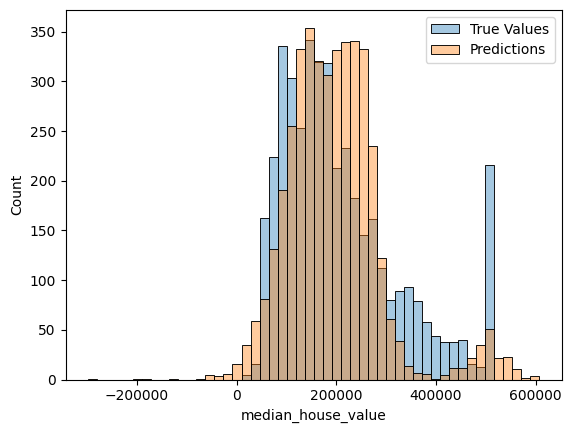

In [56]:
fig3, ax3 = plt.subplots()
bin_edges = np.linspace(min(yTestTrueLog.min(), y_predLog.min()),
                       max(yTestTrueLog.max(), y_predLog.max()),
                       51)  # 50 bins, 51 edges
sns.histplot(yTestTrueLog, bins=bin_edges, label='True Values', kde=False, alpha=0.4, ax=ax3)

sns.histplot(y_predLog, bins=bin_edges, label='Predictions', kde=False, alpha=0.4, ax=ax3)

ax3.legend()


print('Mean Absolute Error:', sklearn.metrics.mean_absolute_error(yTestTrueLog, y_predLog))
print('Root Mean Squared Error:', sklearn.metrics.mean_squared_error(yTestTrueLog, y_predLog)**0.5)

print('Predictions < $0:', (testPredicitions < 0).sum())
print('Predictions > $500,000:', (testPredicitions > 500000).sum())

- With taking log of house price some are hugely overpredicted